# 07 — XGBoost Nowcasting

This notebook mirrors `06_dfm_nowcasting.ipynb` so that XGBoost results are **directly comparable** with the DFM (A-CD-TPN) and DFM-SV benchmarks on the same pseudo-real-time schedule:

* **Evaluation window:** 2011Q1 – 2025Q4 (60 quarters, M3).
* **Information set:** identical real-time `pub_lag_map` masking, AR(p) BIC ragged-edge fill, and quarterly aggregation as `06_dfm_nowcasting.ipynb`. XGB-Full uses the full coverage-eligible panel (not the Stage-03 selection matrices — tested separately in prior experiments; Full outperformed EN/Core/PLS). GDP lags L1–L2 are appended as autoregressive features, closing the structural gap with the DFM state-space representation.
* **Specification:** **XGB-Full** — all ~580 monthly series passing 30% coverage (origin-specific), SHAP-pruned every 4 quarters (90% cumulative |SHAP| mass, floor 20 base series); in practice ~170–200 base series are retained, yielding ~510–600 indicator lag-columns (L0–L2) **plus GDP lags L1 and L2**, for ~512–602 total features.
* **Metrics:** RMSFE, NSR (Lehmann et al. 2020), Diebold–Mariano vs AR(1) (HLN-corrected), regime splits.

XGBoost is included as a **non-linear ML benchmark** and to provide SHAP-based variable importance that complements EN/PLS selection frequencies from Part I.

**Why Full panel?** Prior experiments showed XGB-EN, XGB-Core, and XGB-PLS all performed worse than XGB-Full (in-sample SHAP screening outperforms the linear Part I screens for a non-linear learner). This is consistent with Goulet Coulombe et al. (2022), who find tree ensembles benefit from larger predictor sets via self-regularisation.

**References.** Chen & Guestrin (2016); Medeiros et al. (2021); Goulet Coulombe et al. (2022); Lundberg & Lee (2017); Lehmann, Reif & Wollmershäuser (2020).


## §0  Setup

In [ ]:
from __future__ import annotations
%matplotlib inline
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio

pio.renderers.default = "plotly_mimetype"

# --- Portable repository setup ---
_repo = next(
    (base for base in (Path.cwd(), *Path.cwd().parents)
     if (base / "src" / "german_gdp_nowcasting").is_dir()),
    None,
)
if _repo is None:
    raise RuntimeError("Could not locate src/german_gdp_nowcasting.")
_src = _repo / "src"
if str(_src) not in sys.path:
    sys.path.insert(0, str(_src))

from german_gdp_nowcasting.config import paths as _tp
from german_gdp_nowcasting.models.xgboost import xgb_utils as xu
from german_gdp_nowcasting.visualization import xgb_plots as xp
from german_gdp_nowcasting.selection.core_utils import (
    load_monthly_panel,
    load_pub_lag_map,
    load_trafo_map,
    build_coverage_mask,
    make_monthly_forecast_origins,
)
from german_gdp_nowcasting.models.dfm.nowcast_utils import (
    compute_rmsfe,
    compute_nsr,
    diebold_mariano_test,
    build_rmsfe_table,
    align_forecast_errors,
)

xp.setup_style()
HEADLINE_MIQ = xu.HEADLINE_MIQ  # M3 end-of-quarter, matching notebook 06
EVAL_START = "2011Q1"
EVAL_END = "2025Q4"
TRAIN_START = "1991Q1"
TUNE_END = "2010Q4"   # pre-evaluation tuning window
GDP_LAGS = (1, 2)      # quarterly AR lags appended to every design matrix
# Expensive loops and tuning are opt-in.
FORCE_RERUN_LOOPS = False
FORCE_RETUNE = False
OUT_DIR = _tp.OUT_NOWCASTING
FIG_DIR = _tp.NOWCAST_FIGURES_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Eval window: {EVAL_START} – {EVAL_END}")
print(f"GDP AR lags: {GDP_LAGS}")


## §1  Load inputs

Same inputs as `06_dfm_nowcasting.ipynb`: transformed monthly panel, publication-lag map, GDP first-release target, and the transformation map produced upstream.


In [2]:
X_monthly = load_monthly_panel(_tp.PANEL_TRANSFORMED_CSV)
pub_lag_map = load_pub_lag_map(_tp.PUB_LAG_CSV)
trafo_map = load_trafo_map(_tp.DATA_DICT_ENRICHED_CSV)
_y_raw = pd.read_csv(_tp.GDP_TARGET_CSV)
_y_raw["quarter"] = pd.PeriodIndex(_y_raw["quarter"], freq="Q")
y_quarterly = _y_raw.set_index("quarter").iloc[:, 0]
y_quarterly.name = "gdp"
forecast_origins = make_monthly_forecast_origins("2011-01", "2025-12")
quarterly_origins = pd.period_range(EVAL_START, EVAL_END, freq="Q")
print(f"X_monthly         : {X_monthly.shape}  ({X_monthly.index.min().date()} → {X_monthly.index.max().date()})")
print(f"y_quarterly       : {y_quarterly.shape}  ({y_quarterly.index.min()} → {y_quarterly.index.max()})")
print(f"pub_lag_map       : {pub_lag_map.shape}")
print(f"quarterly origins : {len(quarterly_origins)} quarters")


X_monthly         : (420, 585)  (1991-01-01 → 2025-12-01)
y_quarterly       : (139,)  (1991Q2 → 2025Q4)
pub_lag_map       : (585,)
quarterly origins : 60 quarters


## §2  Real-time information set & mixed frequency

**DFM (stage 04):** monthly indicators + quarterly GDP in a Mariano–Murasawa `DynamicFactorMQ` system; Kalman filtering updates the nowcast at **M1/M2/M3**. Past GDP enters the state space implicitly via the Kalman recursion.

**XGB (this notebook):** same **two-stage ragged edge** as the DFM (publication-lag mask → AR(p) BIC fill in \(Q(t)\)), then the **raw-level aggregation bridge** (central `aggregation` module): the masked + AR-filled transformed months are back-transformed to raw levels, aggregated to a **quarterly mean** of the raw monthly levels, and re-transformed (identity for level-stationary series, quarterly Δln for growth series). Quarterly lags \(L0,L1,L2\) of each indicator follow. XGB does **not** model mixed frequency jointly; it predicts quarterly GDP from a tabular feature matrix.

To close the structural gap with the DFM, **GDP autoregressive lags L1 and L2** are appended to the design matrix at every origin. These are always observable at M3 of quarter \(q\): first-release GDP for \(q-1\) is typically published ~30 days after quarter-end, well before M3 of \(q\) (Bańbura et al. 2013). Including GDP lags also ensures XGBoost can replicate AR(1) benchmark behaviour when indicators add no incremental signal.

**Headline evaluation uses M3 only** (60 origins), matching the primary metric in `06_dfm_nowcasting.ipynb`.


## §3  Hyperparameter tuning

Tuning is performed **once** on the pre-evaluation window 1991Q1–2010Q4 using `RandomizedSearchCV` over `TimeSeriesSplit(5)`. Search space (`xgb_utils.DEFAULT_SEARCH_SPACE`):

* `n_estimators`     ∈ {200, 300, 400, 500, 600}
* `max_depth`        ∈ {2, 3, 4, 5, 6}
* `learning_rate`    ∈ {0.01, 0.025, 0.05, 0.075, 0.1}
* `subsample`        ∈ {0.6, 0.7, 0.8, 0.9, 1.0}
* `colsample_bytree` ∈ {0.5, 0.7, 0.8, 1.0}
* `min_child_weight` ∈ {1, 2, 4, 6, 10}
* `reg_alpha`        ∈ {0, 0.001, 0.01, 0.1, 1.0}
* `reg_lambda`       ∈ {0.5, 1.0, 2.0, 5.0}

**Tuning design:** hyperparameters are tuned on the **core indicator set + GDP lags L1–L2** (~93 indicator columns + 2 GDP lag columns ≈ ~95 features total). This is a deliberate regularisation choice: a prior experiment tuning on the full panel (~1 735 pre-SHAP columns) yielded worse out-of-sample RMSFE (M3 = 1.64 vs 1.42 for core-tuned), likely because CV on the full high-dimensional design is harder to optimise reliably in a short sample (n ≈ 80 training quarters). The core design is representative of the regime encountered after SHAP pruning in §4 (~170–200 retained base series). The tuned params are reused for every origin in §4 without re-fitting.

The cached parameters in `outputs/nowcasting/xgb_best_params.json` were obtained with this design (including GDP lags L1–L2); `FORCE_RETUNE = False` in §0 reuses the cache so the notebook is fully reproducible without re-running the search.

In [3]:
params_cache = xu.load_params(_tp.XGB_BEST_PARAMS_JSON)
if params_cache is not None and not FORCE_RETUNE:
    BEST_PARAMS = params_cache["params"]
    print("Loaded cached XGB hyperparameters:")
    for k, v in BEST_PARAMS.items():
        print(f"  {k:>17s}: {v}")
    print(f"  cached CV RMSE  : {params_cache.get('cv_rmse', float('nan')):.4f}")
else:
    # Only core selection matrix is needed for tuning (see §3 markdown for rationale).
    tune_sel = pd.read_csv(_tp.CORE_MATRIX_CSV, index_col="forecast_origin").astype(int)
    tune_origin = pd.Period("2010-12", freq="M")
    tune_q = tune_origin.asfreq("Q")
    m3_key = str(xu.quarter_to_m3_period(tune_q))
    if m3_key not in tune_sel.index:
        earlier = tune_sel.index[tune_sel.index <= m3_key]
        m3_key = earlier[-1] if len(earlier) > 0 else tune_sel.index[0]
    tune_cols = tune_sel.columns[tune_sel.loc[m3_key].astype(bool)].tolist()
    print(f"Tuning origin {tune_origin} (core row {m3_key}, N={len(tune_cols)} indicators + GDP lags {GDP_LAGS})")
    X_tr, y_tr, _ = xu.build_xgb_design_matrix(
        X_monthly=X_monthly, y_quarterly=y_quarterly, origin=tune_origin,
        selected_cols=tune_cols, pub_lag_map=pub_lag_map,
        lags=xu.DEFAULT_LAGS, train_start=TRAIN_START, trafo_map=trafo_map,
        fill_method="ar_bic", gdp_lags=GDP_LAGS,
    )
    print(f"Tuning design matrix: {X_tr.shape}")
    hp = xu.tune_xgb(X_tr, y_tr, n_iter=40, cv_splits=5)
    BEST_PARAMS = hp.params
    xu.save_params(_tp.XGB_BEST_PARAMS_JSON, hp)
    print(f"Best CV RMSE = {hp.cv_rmse:.4f}")
    print("Best params:")
    for k, v in BEST_PARAMS.items():
        print(f"  {k:>17s}: {v}")


Tuning origin 2010-12 (core row 2011-01, N=30 indicators + GDP lags (1, 2))
Tuning design matrix: (78, 92)
Best CV RMSE = 0.6656
Best params:
          subsample: 0.6
         reg_lambda: 1.0
          reg_alpha: 0.0
       n_estimators: 500
   min_child_weight: 1
          max_depth: 6
      learning_rate: 0.025
   colsample_bytree: 0.7


## §4  Expanding-window XGBoost loop

**XGB-Full** uses all ~580 monthly series passing 30% real-time coverage. At each origin the full design matrix is first built, then SHAP-guided pruning selects the most informative features:

| Component | Detail |
|---|---|
| Monthly indicators | ~580 series × 3 lags (L0–L2) ≈ ~1 740 columns pre-SHAP |
| SHAP pruning | every 4 quarters; 90% cumulative \|SHAP\| mass, floor 20 base series |
| Retained indicators | ~170–200 base series × 3 lags ≈ ~510–600 indicator columns post-SHAP |
| GDP AR lags | L1 and L2 — always retained, never pruned |
| **Total features** | **~512–602 columns per origin** |

**Does SHAP pruning help?** Yes, partially: it reduces the indicator column count from ~1 740 to ~510–600 (≈65% reduction), preventing the model from chasing spurious cross-correlations among rarely-used series. However, even post-SHAP, the design is still high-dimensional relative to training observations (n ≈ 80 at the first origin), so the primary regularisation comes from `subsample`, `colsample_bytree`, and `reg_lambda` in the XGB learner itself. SHAP pruning is best understood as a *computational* and *interpretability* tool (it reveals which series truly drive the forecast) rather than a cure for the dimensionality problem.

**GDP lags L1–L2** are appended after SHAP pruning and are always retained. They are the single most important structural fix: without them, XGBoost cannot replicate even an AR(1) baseline, since past GDP growth is not represented anywhere in the indicator set. With them, the model can downweight noisy indicators and rely on GDP persistence whenever the signal-to-noise ratio of the monthly panel is low.

The training window expands from 1991Q1 to q−1 at each origin; hyperparameters from §3 are reused without re-fitting.

If the result CSV already exists and `FORCE_RERUN_LOOPS = False`, the loop is skipped and results are loaded from cache. **Set `FORCE_RERUN_LOOPS = True` once after updating GDP lags or HP.**


In [ ]:
coverage_mask = build_coverage_mask(X_monthly, forecast_origins, min_coverage=0.30)
xgb_results: dict[str, pd.DataFrame] = {}
xgb_shap_logs: dict[str, pd.DataFrame] = {}
FULL_KEY = "full"
csv_full = _tp.xgb_results_csv(FULL_KEY)
shap_csv = _tp.XGB_SHAP_IMPORTANCE_CSV
if xu.needs_run(csv_full, force=FORCE_RERUN_LOOPS):
    print("\n>>> XGB-Full (with SHAP-guided pruning every 4 quarters)")
    print("Full-panel: origin-specific coverage (≥30%), SHAP prune every 4Q")
df_full, shap_log = xu.run_xgb_nowcast_loop(
    selection_matrix=None,
    X_monthly=X_monthly,
    y_quarterly=y_quarterly,
    params=BEST_PARAMS,
    quarterly_origins=quarterly_origins,
    pub_lag_map=pub_lag_map,
    lags=xu.DEFAULT_LAGS,
    train_start=TRAIN_START,
    trafo_map=trafo_map,
    fill_method="ar_bic",
    gdp_lags=GDP_LAGS,
    coverage_mask=coverage_mask,
    shap_pruning=True,
    shap_refit_every=4,
    shap_keep_frac=0.90,
    shap_min_features=20,
    shap_log_every=1,
    verbose=True,
)
df_full.to_csv(csv_full)
if not shap_log.empty:
        shap_log.to_csv(shap_csv)
else:
    print(f"<<< XGB-Full loaded from cache: {csv_full.name}")
    df_full = pd.read_csv(csv_full, index_col="quarter")
    shap_log = (pd.read_csv(shap_csv).set_index(["quarter", "feature"])
                if shap_csv.exists() else pd.DataFrame())
xgb_results["XGB-Full"] = df_full
xgb_shap_logs["XGB-Full"] = shap_log



In [6]:
# Save with empirical 90% prediction interval.
df_full = xu.compute_xgb_intervals(xgb_results["XGB-Full"], alpha=0.10, min_history=8)
xgb_results["XGB-Full"] = df_full
df_full.to_csv(_tp.xgb_results_csv("full"))
summary = pd.DataFrame({
    "XGB-Full": {
        "n_obs":         int(df_full["nowcast"].notna().sum()),
        "RMSFE":         compute_rmsfe(df_full, EVAL_START, EVAL_END, month_in_quarter=HEADLINE_MIQ),
        "mean_features": float(df_full["n_features"].mean()) if "n_features" in df_full else float("nan"),
    }
}).T
summary.round(4)


,n_obs,RMSFE,mean_features
XGB-Full,60.0,1.4313,606.0


## §5  SHAP analysis (XGB-Full)

Mean |SHAP| per (base) feature averaged over the SHAP-refit quarters; bar chart with cross-time dispersion as error bars.


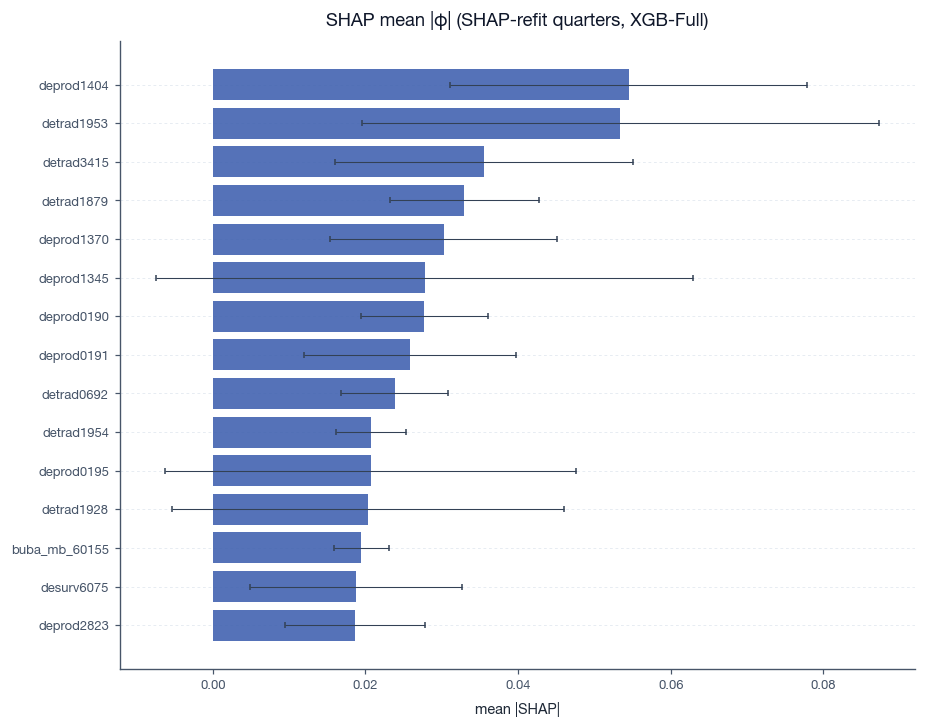

Top 15 variables by mean |SHAP| (full names from data dict):

  deprod1404
    Germany, Industrial Production, Total, Calendar Adjusted (X13 JDemetra+), Constant Prices, SA (X13 JDemetra+), Index

  detrad1953
    Germany, Production Sales, Turnover, Durable Goods, Total, Calendar Adjusted (X13 JDemetra+), Constant Prices, SA (X13 JDemetra+), Index

  detrad3415
    Germany, Production Sales, Turnover, Manufacturing, Domestic Markets, Calendar Adjusted (X13 JDemetra+), Constant Prices, SA (X13 JDemetra+), Index

  detrad1879
    Germany, Production Sales, Turnover, Intermediate Goods, Domestic Markets, Calendar Adjusted (X13 JDemetra+), Constant Prices, SA (X13 JDemetra+), Index

  deprod1370
    Germany, Industrial Production, Total, Excluding Construction, Calendar Adjusted (X13 JDemetra+), Constant Prices, SA (X13 JDemetra+), Index

  deprod1345
    Germany, Industrial Production, By Goods, Intermediate Goods, Calendar Adjusted (X13 JDemetra+), Constant Prices, SA (X13 JDemetra+), I

In [7]:
shap_log = xgb_shap_logs.get("XGB-Full", pd.DataFrame())
TOP_SHAP = 15
fig = xp.fig_shap_bar(shap_log, top_n=TOP_SHAP, aggregate_lags=True)
xp.save_fig(fig, FIG_DIR / "xgb_05_shap_bar.png"); plt.show()
# Same ranking as ``fig_shap_bar`` (aggregate lags → base series id).
if shap_log.empty:
    print("No SHAP log — no top variables to list.")
else:
    shap_df = shap_log.reset_index()
    shap_df["feature_base"] = shap_df["feature"].map(
        lambda c: c.rsplit("__L", 1)[0] if "__L" in c else c
    )
    agg = shap_df.groupby(["quarter", "feature_base"], as_index=False)["mean_abs_shap"].sum()
    stats = (
        agg.groupby("feature_base")["mean_abs_shap"]
        .agg(["mean", "std"])
        .sort_values("mean", ascending=False)
        .head(TOP_SHAP)
    )
    name_map = (
        pd.read_csv(_tp.DATA_DICT_ENRICHED_CSV, usecols=["id", "name"])
        .drop_duplicates(subset="id")
        .set_index("id")["name"]
    )
    print(f"Top {TOP_SHAP} variables by mean |SHAP| (full names from data dict):\n")
    for sid in stats.index:
        full = name_map.get(sid, "(no matching id in data_dict_enriched.csv)")
        print(f"  {sid}\n    {full}\n")


In [8]:
# Plotly — SHAP mass by indicator category (hover / zoom)
if shap_log.empty:
    print("No SHAP log — run XGB-Full in §4 first.")
else:
    _dd = pd.read_csv(_tp.DATA_DICT_ENRICHED_CSV)
    cat_map = _dd.set_index("id")["category"]
    xp.fig_xgb_shap_category_interactive(shap_log, cat_map, show=True)

## §6  Evaluation — RMSFE, NSR, DM vs AR(1)

We load **all DFM / DFM-SV outputs already produced by `06_dfm_nowcasting.ipynb`** from `outputs/nowcasting/` and combine them with the new XGB results in a single comparison table. The benchmark models (RW, AR(1)) from notebook 06 are loaded too so the user sees the full ranking.

Diebold–Mariano p-values vs **AR(1)** (the standard nowcasting benchmark) use the squared-error loss and the HLN small-sample correction (Harvey, Leybourne & Newbold 1997).

**NSR < 1** is the practical-relevance threshold of Lehmann, Reif & Wollmershäuser (2020): a model with NSR < 1 produces errors smaller than the natural variability of the target series.


In [11]:
def _read_results(path: Path) -> pd.DataFrame:
    """Load nowcast CSV; keep monthly_origin / month_in_quarter for M3 filtering."""
    return pd.read_csv(path)


In [ ]:
DFM_FILES = {
    "AR1":                _tp.AR1_RESULTS_CSV,
    "RW":                 _tp.RW_RESULTS_CSV,
    "DFM-ifoCAST":        _tp.IFO_RESULTS_CSV,
    "DFM-EN":             _tp.actpn_results_csv("en_only"),
    "DFM-BlockBalanced":  _tp.BLOCKBALANCED_RESULTS_CSV,
    "DFM-SV-k2":          _tp.ACTPN_SV_RESULTS_K2_CSV,
    "combo_equal":        _tp.COMBO_EQUAL_PATH_CSV,
}
all_results: dict[str, pd.DataFrame] = {}
for name, p in DFM_FILES.items():
    if Path(p).exists():
        all_results[name] = _read_results(Path(p))
# XGB-Full from §4–§5 (or reload from disk if kernel was restarted)
if "xgb_results" not in globals() or "XGB-Full" not in xgb_results:
    p_full = _tp.xgb_results_csv("full")
    if Path(p_full).exists():
        xgb_results = {"XGB-Full": pd.read_csv(p_full, index_col="quarter")}
all_results.update(xgb_results)
print(f"Loaded {len(all_results)} models: {list(all_results.keys())}")


In [ ]:
rmsfe_table = build_rmsfe_table(
    all_results,
    reference_key="DFM-EN",
    eval_start=EVAL_START,
    eval_end=EVAL_END,
    y_quarterly=y_quarterly,
    month_in_quarter=HEADLINE_MIQ,
)
ar1_df = all_results.get("AR1", pd.DataFrame())
dm_rows = []
for name, df in all_results.items():
    if name == "AR1":
        continue
    e_a, e_b = align_forecast_errors(df, ar1_df, month_in_quarter=HEADLINE_MIQ)
    if len(e_a) < 8:
        dm_p = np.nan
    else:
        dm_p = diebold_mariano_test(e_a, e_b, h=1, loss="se")["p_value"]
    dm_rows.append({"model": name, "DM_vs_AR1_p": dm_p})
dm_df = pd.DataFrame(dm_rows).set_index("model")
rmsfe_table = rmsfe_table.join(dm_df, how="left")
if "AR1" in rmsfe_table.index:
    ar1_rmsfe = rmsfe_table.at["AR1", "RMSFE"]
    rmsfe_table["vs_AR1"] = rmsfe_table["RMSFE"] / ar1_rmsfe
rmsfe_table = rmsfe_table.sort_values("RMSFE")
rmsfe_table.to_csv(_tp.RMSFE_TABLE_XGB_CSV)
display(rmsfe_table.round(4))


## §7  Regime splits

RMSFE and MAE per model across three sub-samples:

| Period | Window |
|---|---|
| Pre-COVID | 2011Q1 – 2019Q4 |
| COVID | 2020Q1 – 2021Q4 |
| Post-COVID | 2022Q1 – 2025Q4 |


In [ ]:
from german_gdp_nowcasting.models.dfm.nowcast_utils import _subset_eval_window

REGIMES = {
    "pre-COVID": ("2011Q1", "2019Q4"),
    "COVID": ("2020Q1", "2021Q4"),
    "post-COVID": ("2022Q1", "2025Q4"),
}
split_rows = []
for name, df in all_results.items():
    row = {"model": name}
    for reg, (a, b) in REGIMES.items():
        row[f"RMSFE_{reg}"] = compute_rmsfe(
            df, a, b, month_in_quarter=HEADLINE_MIQ,
        )
        sub = _subset_eval_window(
            df, eval_start=a, eval_end=b, month_in_quarter=HEADLINE_MIQ,
        )
        errs = sub["error"].dropna()
        row[f"MAE_{reg}"] = float(errs.abs().mean()) if len(errs) else np.nan
    split_rows.append(row)
split_table = pd.DataFrame(split_rows).set_index("model").round(4)
split_table


### Files written

* `nowcast_results_xgb_full.csv` — per-quarter nowcasts with `ci_lower_90`/`ci_upper_90` empirical prediction intervals.
* `xgb_shap_importance.csv` — SHAP `mean |φ|` log for XGB-Full (every quarter × features; deployed model, decoupled from the 4-quarter pruning refit).
* `xgb_best_params.json` — hyperparameters from §3 (reused at every origin).
* `rmsfe_table_with_xgb.csv` — RMSFE / NSR / vs-AR1 / DM table (all loaded models).
* `figures/xgb_05_shap_bar.png` — top-15 SHAP importance bar chart (XGB-Full).

### Interpretation

* **XGB vs DFM-EN.** On the thesis specification XGB-Full has full-sample RMSFE 1.386 against 0.784 for DFM-EN. The deficit is concentrated in COVID (3.704 against 1.921). After 2022 the point estimate looks better (0.248 against 0.451), but five seeds of the same pipeline span 0.248–0.618, so it is a diagnostic rather than a headline nowcast. Neither full-sample gap is certified at this sample size. Non-linearity is not the binding constraint; the break and the short sample are.
* **SHAP vs EN/PLS.** Both tilt towards hard activity. Series-level rank correlation with the elastic net is only 0.375 — the same weak membership agreement as the rest of Part I, not a shared indicator list.
* **NSR < 1** is the practical-relevance threshold of Lehmann, Reif and Wollmershäuser (2020). After 2022 even the best model's RMSFE exceeds the target's own standard deviation (0.187).
